**Objectives** In this lesson, you will learn:
*  how to review fitting a logarithmic model using scipy.optimize.curve_fit
*  how to evaluate model accuracy using Mean Squared Error (MSE)
*  how to fit polynomial logarithmic and power law models
*  how to compare model performance across different nonlinear models

### 5.1 Testing Log regression

Let's use a logarithmic function as the function for the curve fit method :
https://www.geeksforgeeks.org/how-to-do-exponential-and-logarithmic-curve-fitting-in-python/


$y = a*ln(x) + b$

In [ ]:
# Define a nonlinear model (logarithmic) to fit to the data
def log_model(x, a, b):  # function to calculate y for our formula (log model)
    # Calculate the y value for the logarithmic function using the given parameters 'x', 'a' and 'b'
    y = a * np.log(x) + b
    return y

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# defining our data like normal
x = data_clean['Curing time (days)']
y = data_clean['Lime water (N/mm2)']

# Fit the nonlinear model to the data
popt, pcov = curve_fit(log_model, x, y)

In [ ]:
## Let's see **what the curve_fit function is returning to us**!

print('popt:\n',popt)
print('pcov:\n',pcov)

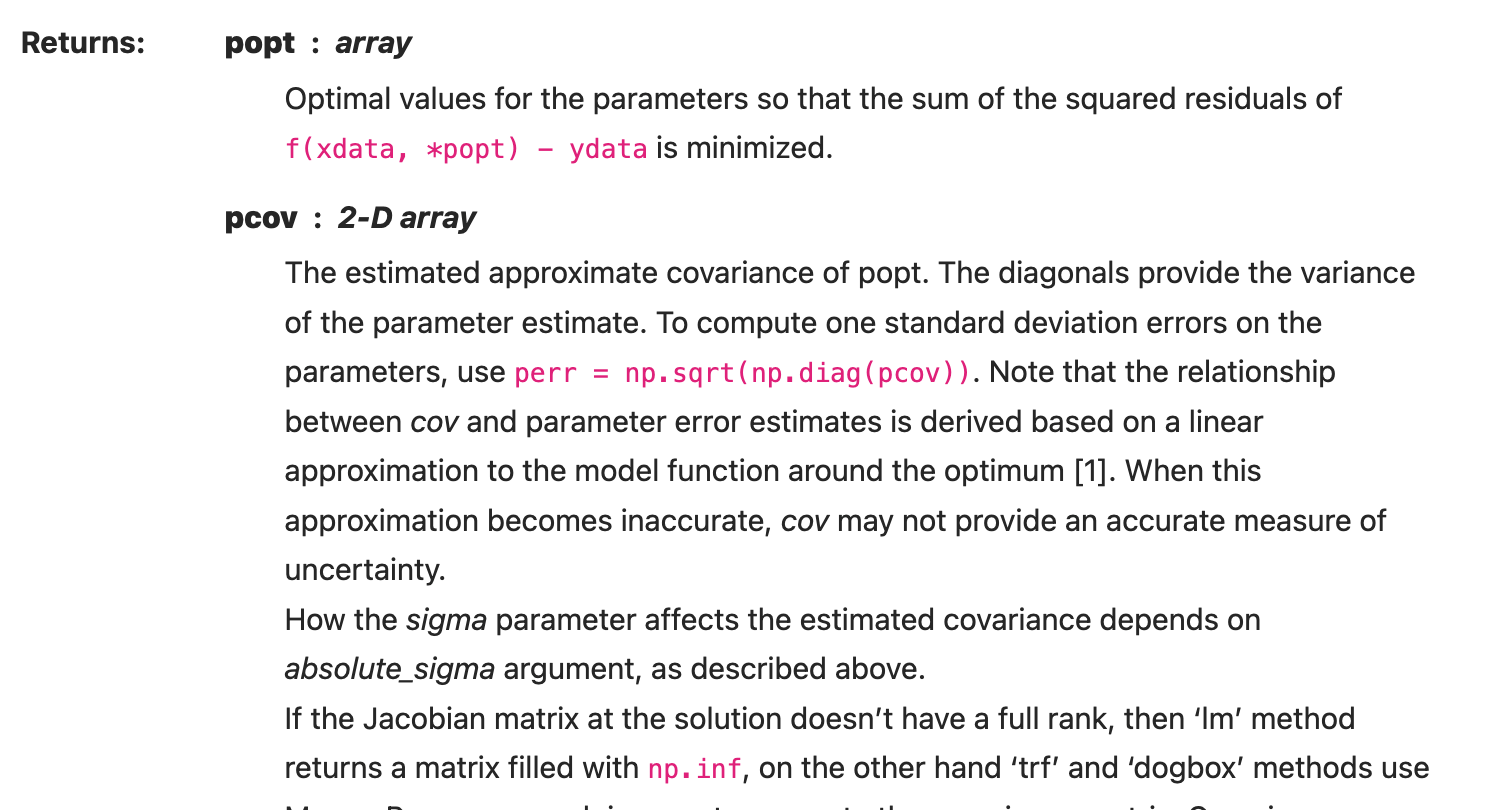



#### Parameter popt
**popt returns a list of the parameters/coefficients - function constants - we are trying to fit with our model**. So if we look at our model above, we said we were trying to fit 2 parameters, and we called them a and b in that order.

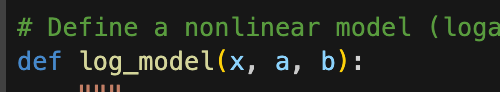

so this means

# a = popt[0]
# b = popt[1]

In [ ]:
a = popt[0]
b = popt[1]

In [ ]:
# and the equation would look like:
print('y = {} * log(x) + {}'.format(round(a, 2), round(b,2)))

### Visualizing the predicted values using curve_fit() with log

So let's **use the popt values to predicted y log values**, make a scatter plot of the original data, and then plot our new log based prediction on top of that

In [ ]:
# Predicting values using the log model with the coefficients from curve fit
predicted_y_log = log_model(x, popt[0], popt[1])

# Plot scatter plot
fig, ax = plt.subplots()
ax.scatter(x, y, label='Measured data')

# Plot nonlinear fit
ax.plot(x, predicted_y_log, color='red', label='Log fit')

ax.set_xlabel('Curing time (days)')
ax.set_ylabel('Concrete Strength (N/mm2)')
ax.set_title('Concrete Strength vs Curing time - Lime Water method')
ax.legend()
plt.show()

### 5.3 Verifying the estimation/prediction using MSE

Another way to quantify how well our line of best fit fits our data is using mean squared error.

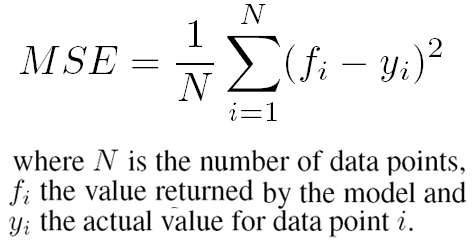

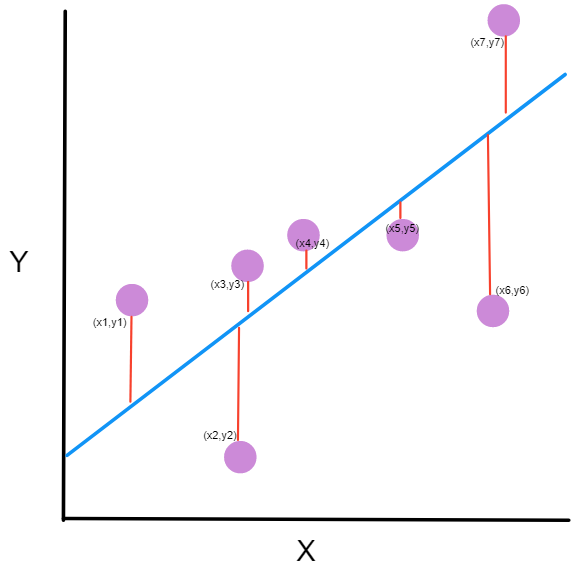

There are a lot of ways to implement this: from scratch (we develop the script/function) or we can use different packages. Let's try one of those packages.

Here is the syntax we can use:



```
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, predicted_y)
```



In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# defining our data - considering the Lime water method
x = data_clean['Curing time (days)']  # x = curing time
y = data_clean['Lime water (N/mm2)']  # y = concrete strength for lime water method

# Fit the nonlinear model to the data
popt, pcov = curve_fit(log_model, x, y)  # we which we have define log_model previously

# Predicting values using the fitted nonlinear model
predicted_y_log = log_model(x, popt[0], popt[1])
mse_log = mean_squared_error(y, predicted_y_log)  # mean squared error
print('mse: ',mse_log)


So how do I know if this is any good?

Mean Squared Error (MSE) is a measure of the average squared difference between the predicted values and the actual values in a regression model. In general, a lower MSE indicates a better fit of the model to the data. However, whether an MSE value is considered "good" or not depends on the specific context and goals of the analysis.

Here are some factors to consider when interpreting MSE:

* Comparative Analysis: MSE is most informative when comparing multiple models fitted to the same dataset. In this case, the model with the lowest MSE is generally preferred, as it indicates the best overall fit to the data among the models considered.

* Scale of the Response Variable: MSE is sensitive to the scale of the response variable. A "good" MSE value is relative to the scale of the variable being predicted. For example, an MSE of 10 might be acceptable for predicting housing prices in thousands of dollars, but not for predicting temperatures in degrees Celsius.

So looking back at our data, **on a scale of 12-30 N/mm2** a mean squared error of **0.25 N/ mm2 is pretty ...**!


**good!**

### 5.4 Testing Polynomial log function

Okay well that was a log function, are there other types of nonlinear models we could compare to see if they do a better job modeling this data?

We could fit a **polynomial function** to this data and see if the performance improves.
Let's create a new model with more parameters.

$y = a \; ln(x)^2 + b\; ln(x) + c$

In [ ]:
# let's define a polynomial logarithmic regression:
def poly_log_model(x, a, b, c):
    return a * np.log(x)**2 + b * np.log(x) + c

In [ ]:
# getting coefficients using curve fit for poly log model
coeff, cov = curve_fit(poly_log_model, x, y)
print('Coefficients = ',coeff)
print('Covariance matrix = ',cov)

# predicting y values using poly_log_model and the coefficients from curve fit
a, b, c = coeff
predicted_y_poly = poly_log_model(x, a, b, c)

# mean squared error
mse_poly = mean_squared_error(y, predicted_y_poly)
print('MSE = ', mse_poly)

In [ ]:
# plotting original data and predicted data using poly log

# Plot scatter plot
fig, ax = plt.subplots()
ax.scatter(x, y, label='Measured data')

# Plot nonlinear fit
ax.plot(x, predicted_y_log, color='red', label='Log fit')
ax.plot(x, predicted_y_poly, color='green', label='Poly log fit')

ax.set_xlabel('Curing time (days)')
ax.set_ylabel('Concrete Strength (N/mm2)')
ax.set_title('Concrete Strength vs Curing time - Lime Water method')
ax.legend()
plt.show()

#### **Doing prediction for all datasets!**

We've done prediction for only the lime water curing method. What if we wanted to predict concrete strength across all different curing methods (different columns)? We could do this using the **enumerate** function.

You can also do this one at a time and add them to the same axes if you are more comfortable with that. This is just an alternate method for those interested in doing it as a loop.

In [ ]:
# what are all of my variables I am trying to plot
variables = data_clean.columns[1:]  # concrete strength for all curing methods
poly_mse = np.zeros_like(variables) # makes an array of zeros with the size of variables

# create my plot with fig, ax
fig, ax = plt.subplots()

# for loop loop over all my variables
for i, v in enumerate(variables):

  # x data (same so define inside or outside)
  xdata = data_clean['Curing time (days)']
  # y data is what i am looping through
  ydata = data_clean[v]

  # plot scatter plot
  ax.plot(xdata, ydata, '.')

  # curve fit using poly log for now
  params, cov = curve_fit(poly_log_model, xdata, ydata)
  # prediction
  a, b, c = params
  # calculate the predicted values using these parameters and the poly log model
  prediction = poly_log_model(x, a, b, c)

  # plot my curve
  ax.plot(xdata, prediction)

  # calculate my mse and store
  poly_mse[i] = mean_squared_error(ydata, prediction)

poly_mse

But what are all the numbers in my array?

Each number in that array is the Mean Squared Error for the corresponding column in your variables list!

And we can visualize this!

In [ ]:
fig, ax = plt.subplots()
x = np.arange(len(variables))
w = 0.2 # set the width of the bars
ax.bar(x-w, poly_mse, width=w) # shift to the left by one bar width
ax.set_xticks(x)
ax.set_xticklabels(list(variables), ha='right', rotation=45)
ax.set_ylabel('Mean Squared Error')

### 5.5 Testing power law function

#### Your Turn Thursday
You can try another common function found in physics, the **power law**:

$y = x^a + b$

In [ ]:
# your turn

Here we can see that the **power law model performs substantially worse** than our polynomial logarithmic regression.
So either we are onto something with that functional form, or at least it has enough degrees of freedom to do a good job.

You can then use a bar chart to compare the MSE from each approach!

In [ ]:
# your turn

---
## 📋 Today's In-Class Assignment

**Your Turn Thursday above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

**Key Takeaways**
* Not all data is linear!!  Many real-world phenomena, like the curing of concrete, exhibit non-linear relationships. It's important to visualize your data to understand its underlying structure.

* Data cleaning should always be your first step! Before modeling, you must handle missing or null values to ensure the accuracy of your model.

* Nonlinear curve fitting is a powerful tool! Using `scipy.optimize.curve_fit`, you can fit a model directly in its actual functional form (logarithmic, polynomial, power law, etc.) instead of needing it to be linear, letting you model far more complex relationships -- and comparing models with MSE lets you choose between them objectively, not just by eye